# 방범용 CCTV 위치와 인구 데이터분석
- https://data.busan.go.kr/
- 부산광역시_방범용 CCTV 정보 검색 -> csv 파일 다운로드

- https://jumin.mois.go.kr/
- CCTV와 같은 날짜의 인구를 검색 -> csv 파일 다운로드

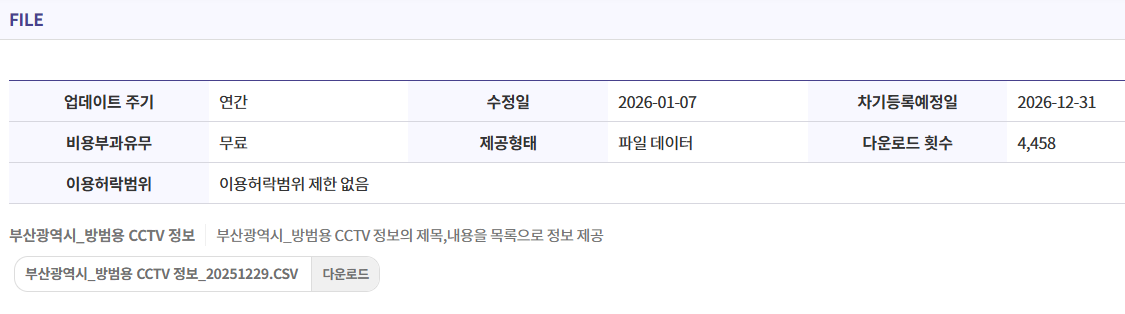
<hr/>

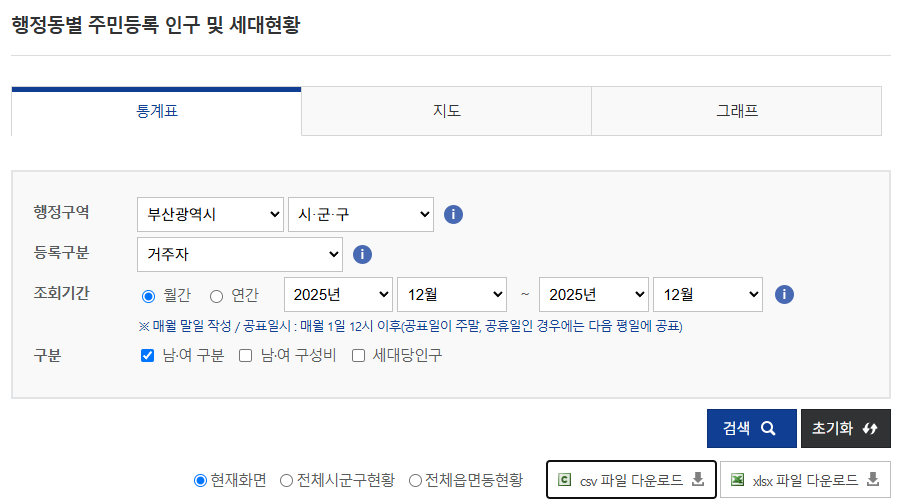

In [11]:
from hdfs import InsecureClient
import pandas as pd
import matplotlib.pyplot as plt

Text(0.2, 0.4, '한글')

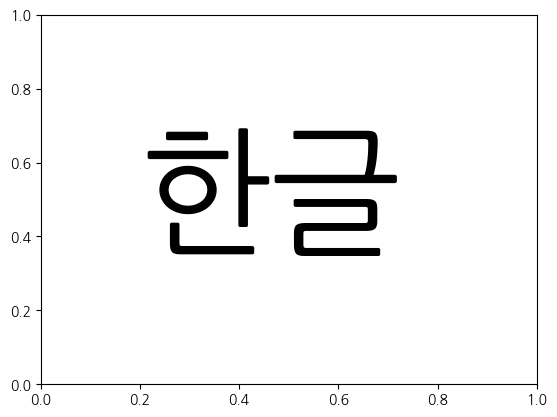

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [22]:
client_hdfs = InsecureClient('http://namenode:9870',user='hadoop')
path_cctv = "/dataset/부산광역시방범용CCTV정보202512.csv"
path_jumin = "/dataset/주민등록인구및세대현황202512.csv"

with client_hdfs.read(path_cctv, encoding='cp949') as reader:
    cctv = pd.read_csv(reader)
with client_hdfs.read(path_jumin, encoding='cp949') as reader:
    jumin = pd.read_csv(reader)
# cctv
# jumin

In [31]:
cctv.rename(columns={'구군':'local'}, inplace=True )
cctv_count = cctv['local'].value_counts()
cctv_count

local
남구      2032
사하구     1823
북구      1714
해운대구    1683
강서구     1668
기장군     1508
부산진구    1477
금정구     1284
연제구     1241
사상구     1082
수영구     1077
동구      1047
서구      1030
중구       819
동래구      799
영도구      776
Name: count, dtype: int64

In [57]:
jumin_data = jumin.loc[1:,'행정구역':'2025년12월_거주자 인구수']
jumin_data.columns = ['local', 'value']
jumin_data['local'] = jumin_data['local'].str.replace('부산광역시 ','')
jumin_data['local'] = [data[0] for data in jumin_data['local'].str.split(' ')]
jumin_data

,local,value
1,중구,"36,223"
2,서구,"101,406"
3,동구,"83,352"
4,영도구,"101,104"
5,부산진구,"363,555"
6,동래구,"272,339"
7,남구,"249,640"
8,북구,"262,076"
9,해운대구,"370,561"
10,사하구,"285,207"
